# Exploración preliminar del conjunto de datos Beijing Multi-Site Air Quality

Esta exploración estudia la calidad del aire en Beijing antes de construir un modelo de predicción temporal. El objetivo posterior es predecir la concentración horaria de **PM2.5** con un horizonte de una hora, utilizando las mediciones de 12 estaciones.

En esta etapa se busca:

1. Consolidar los registros de todas las estaciones.
2. Verificar la estructura, el tamaño y los tipos de datos.
3. Cuantificar los valores faltantes por estación y variable.
4. Describir la distribución de PM2.5.
5. Identificar patrones temporales mediante una serie corta y su autocorrelación.

## Origen de los datos

El dataset proviene del **UCI Machine Learning Repository**:

> Chen, S. (2017). *Beijing Multi-Site Air Quality* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5RK5G

Fuente: [Beijing Multi-Site Air Quality en UCI](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data).

El conjunto contiene mediciones horarias de contaminantes y variables meteorológicas registradas en Beijing entre marzo de 2013 y febrero de 2017. Cada archivo corresponde a una estación.

## Preparación

Se importan las herramientas para leer, resumir y visualizar los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path

## 1. Carga y consolidación

Se leen los 12 CSV y se crea `datetime` para ordenar y alinear las series horarias.

In [2]:
DATA_DIR = Path("data/beijing+multi+site+air+quality+data")
archivos = sorted(DATA_DIR.glob("PRSA_Data_*.csv"))
print(f"Archivos encontrados: {len(archivos)}")
assert len(archivos) == 12, "No se encontraron los 12 archivos esperados."

lista_dfs = [pd.read_csv(f) for f in archivos]
df = pd.concat(lista_dfs, ignore_index=True)

# Crear una columna datetime a partir de year/month/day/hour, para poder trabajar la serie con índice temporal
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])


Archivos encontrados: 12


>  Se consolidaron 420.768 registros, con 35.064 observaciones por estación.

## 2. Estructura

Se revisan dimensiones, tipos y primeras filas para distinguir variables temporales, contaminantes, meteorológicas y de estación.

In [3]:
print("\n Dimensiones del dataset consolidado")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

print("\n Tipos de dato por columna")
df.dtypes


 Dimensiones del dataset consolidado
Filas: 420,768 | Columnas: 19

 Tipos de dato por columna


No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                  object
WSPM               float64
station             object
datetime    datetime64[ns]
dtype: object

In [4]:
print("\n Primeras filas")
df.head()


 Primeras filas


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


>  El DataFrame tiene **19 columnas**: identificadores temporales, seis contaminantes, cinco variables meteorológicas, la dirección del viento, la estación y la nueva marca temporal. Las mediciones numéricas están listas para un análisis cuantitativo, mientras que `wd` requiere codificación si se utiliza como predictor.

## 3. Valores faltantes

Se comparan los faltantes de PM2.5 y del conjunto de variables de medición por estación.

In [5]:
# Columnas de medición real
cols_medicion = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
                  "TEMP", "PRES", "DEWP", "RAIN", "wd", "WSPM"]

grupos_estacion = df.groupby("station")
resumen_faltantes = grupos_estacion.agg(
    registros=("station", "size"),
    na_PM2_5=("PM2.5", lambda serie: serie.isna().sum()),
)
resumen_faltantes["na_total_todas_vars"] = (
    df[cols_medicion].isna().groupby(df["station"]).sum().sum(axis=1)
)
resumen_faltantes = resumen_faltantes.rename(columns={"na_PM2_5": "na_PM2.5"})
resumen_faltantes = resumen_faltantes.sort_values("na_total_todas_vars")

print("\n Resumen de faltantes por estación")
resumen_faltantes


 Resumen de faltantes por estación


,registros,na_PM2.5,na_total_todas_vars
station,,,
Nongzhanguan,35064,628,4090
Gucheng,35064,646,4728
Wanshouxigong,35064,696,5146
Changping,35064,774,5166
Tiantan,35064,677,5277
Guanyuan,35064,616,5279
Wanliu,35064,382,6447
Dingling,35064,779,7015
Aotizhongxin,35064,925,7271


> Nongzhanguan tiene menos faltantes totales (4.090) y Shunyi más (8.523).

## 4. Distribución de PM2.5

Se resumen los valores observados en todas las estaciones.

In [6]:
df["PM2.5"].describe()

count    412029.000000
mean         79.793428
std          80.822391
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         999.000000
Name: PM2.5, dtype: float64

> Hay 412.029 mediciones disponibles de PM2.5. La media es 79,8 µg/m³ y la mediana 55 µg/m³; la diferencia y el máximo de 999 indican una distribución asimétrica con episodios de contaminación elevada.

In [7]:
# Tabla estación x tiempo: cada columna es una estación
piv = df.pivot_table(index="datetime", columns="station", values="PM2.5")

## 5. Patrones temporales

Se observan dos semanas de PM2.5 y la autocorrelación de la serie promedio hasta 48 horas.

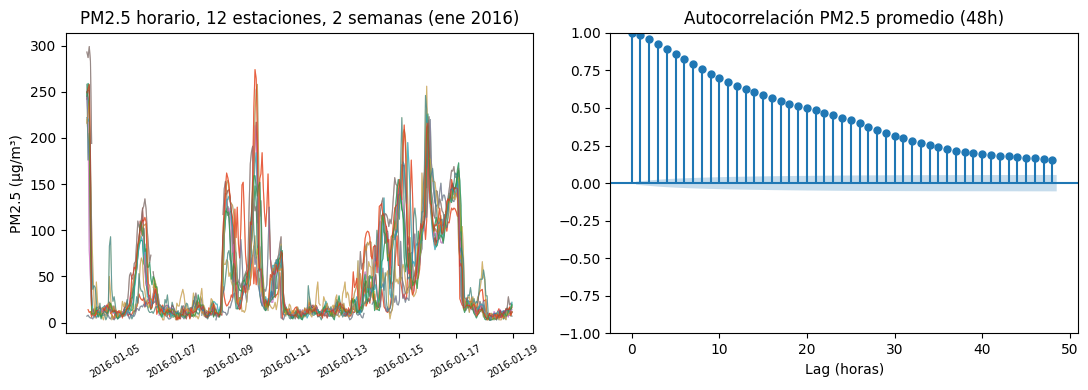

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ventana = piv.loc["2016-01-04":"2016-01-18"]
for col in ventana.columns:
    axes[0].plot(ventana.index, ventana[col], linewidth=0.8, alpha=0.6)
axes[0].set_title("PM2.5 horario, 12 estaciones, 2 semanas (ene 2016)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].tick_params(axis="x", labelrotation=30, labelsize=7)

ventana = piv.loc["2016-01-04":"2016-01-18"]
for col in ventana.columns:
    axes[0].plot(ventana.index, ventana[col], linewidth=0.8, alpha=0.6)
axes[0].set_title("PM2.5 horario, 12 estaciones, 2 semanas (ene 2016)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].tick_params(axis="x", labelrotation=30, labelsize=7)

serie_promedio = piv.mean(axis=1).dropna()
plot_acf(serie_promedio, lags=48, ax=axes[1], title="Autocorrelación PM2.5 promedio (48h)")
axes[1].set_xlabel("Lag (horas)")

plt.tight_layout()

> Las estaciones muestran picos simultáneos de PM2.5 y la autocorrelación permanece positiva durante las 48 horas analizadas.